# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

In [22]:
import pandas as pd
from scipy.io import loadmat

#### 2. Load data
Load the file *ejer_1_data1.mat*. Find the way for loading this kind of file. **scipy.io.loadmat**

In [23]:
data = loadmat("data/ejer_1_data1.mat")
print(data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])


#### 3. Create a DataFrame with the features and target

In [24]:
X = data["X"]
y = data["y"]

In [25]:
X

array([[1.9643  , 4.5957  ],
       [2.2753  , 3.8589  ],
       [2.9781  , 4.5651  ],
       [2.932   , 3.5519  ],
       [3.5772  , 2.856   ],
       [4.015   , 3.1937  ],
       [3.3814  , 3.4291  ],
       [3.9113  , 4.1761  ],
       [2.7822  , 4.0431  ],
       [2.5518  , 4.6162  ],
       [3.3698  , 3.9101  ],
       [3.1048  , 3.0709  ],
       [1.9182  , 4.0534  ],
       [2.2638  , 4.3706  ],
       [2.6555  , 3.5008  ],
       [3.1855  , 4.2888  ],
       [3.6579  , 3.8692  ],
       [3.9113  , 3.4291  ],
       [3.6002  , 3.1221  ],
       [3.0357  , 3.3165  ],
       [1.5841  , 3.3575  ],
       [2.0103  , 3.2039  ],
       [1.9527  , 2.7843  ],
       [2.2753  , 2.7127  ],
       [2.3099  , 2.9584  ],
       [2.8283  , 2.6309  ],
       [3.0473  , 2.2931  ],
       [2.4827  , 2.0373  ],
       [2.5057  , 2.3853  ],
       [1.8721  , 2.0577  ],
       [2.0103  , 2.3546  ],
       [1.2269  , 2.3239  ],
       [1.8951  , 2.9174  ],
       [1.561   , 3.0709  ],
       [1.5495

In [26]:
y

array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1]], dtype=uint8)

In [27]:
df = pd.DataFrame(X, columns=["X", "X2"])
df["target"] = y

In [28]:
df.head()

,X,X2,target
0,1.9643,4.5957,1
1,2.2753,3.8589,1
2,2.9781,4.5651,1
3,2.9320,3.5519,1
4,3.5772,2.8560,1


#### 4. Plot a scatterplot with the data

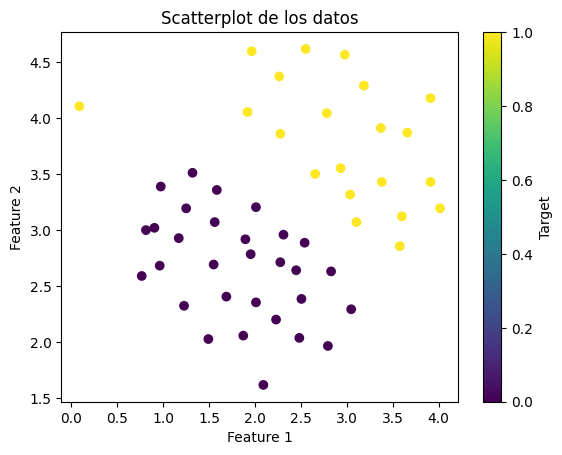

In [29]:
import matplotlib.pyplot as plt

plt.scatter(df["X"], df["X2"], c=df["target"], cmap="viridis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatterplot de los datos")
plt.colorbar(label="Target")
plt.show()

Notice that there is one outlier positive example that sits apart from the others.  The classes are still linearly separable but it's a very tight fit.  We're going to train a linear support vector machine to learn the class boundary.

#### 5. LinearSVC
Declare a Linear SVC with the hyperparamenters:

```Python
LinearSVC(C=1, loss='hinge', max_iter=10000)
```

In [30]:
from sklearn.svm import LinearSVC

model = LinearSVC(C=1, loss="hinge", max_iter=10000)

In [31]:
X = df.drop("target", axis=1)
y = df["target"]

model.fit(X, y)

,penalty,'l2'
,loss,'hinge'
,dual,'auto'
,tol,0.0001
,C,1
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


#### 6. Try the performance (score)
For the first experiment we'll use C=1 and see how it performs.

In [32]:
score = model.score(X, y)
print("Accuracy con C=1:", score)

Accuracy con C=1: 0.9803921568627451


It appears that it mis-classified the outlier.

#### 7. Increase the value of C until you get a perfect classifier

In [33]:
from sklearn.svm import LinearSVC

for C in [1, 5, 10, 50, 100, 500, 1000]:
    model = LinearSVC(C=C, loss="hinge", max_iter=10000)
    model.fit(X, y)
    score = model.score(X, y)
    print(f"C = {C}, score = {score}")

C = 1, score = 0.9803921568627451
C = 5, score = 0.9803921568627451
C = 10, score = 0.9803921568627451
C = 50, score = 0.9803921568627451
C = 100, score = 0.9803921568627451
C = 500, score = 1.0
C = 1000, score = 1.0


c:\Users\Asier\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Asier\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Asier\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Asier\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Asier\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warni

This time we got a perfect classification of the training data, however by increasing the value of C we've created a decision boundary that is no longer a natural fit for the data.  We can visualize this by looking at the confidence level for each class prediction, which is a function of the point's distance from the hyperplane.

#### 8. Plot Decission Function
Get the `decision_function()` output for the first model. Plot a scatterplot with X1, X2 and a range of colors based on `decision_function()`

In [34]:
decision_values = model.decision_function(X)

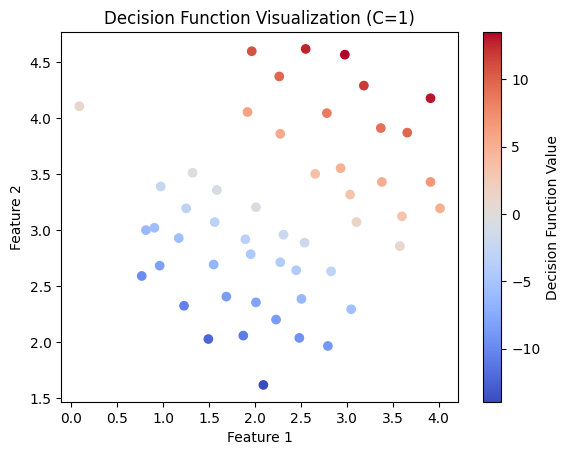

In [35]:
import matplotlib.pyplot as plt

plt.scatter(
    df["X"],
    df["X2"],
    c=decision_values,
    cmap="coolwarm"   # rojo/azul para ver bien la separación
)

plt.colorbar(label="Decision Function Value")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Function Visualization (C=1)")
plt.show()

## 9. Do the same with the second model

https://www.svm-tutorial.com/2015/06/svm-understanding-math-part-3/

#### 1. Load the data `ejer_1_data2.mat`

In [36]:
data_2 = loadmat("data/ejer_1_data2.mat")
print(data_2.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])


#### 2. Create a DataFrame with the features and target

In [37]:
X = data_2["X"]
y = data_2["y"]

In [38]:
df_2 = pd.DataFrame(X, columns=["X", "X2"])
df_2["target"] = y

In [39]:
df_2.head()

,X,X2,target
0,0.107143,0.603070,1
1,0.093318,0.649854,1
2,0.097926,0.705409,1
3,0.155530,0.784357,1
4,0.210829,0.866228,1


#### 3. Plot a scatterplot with the data

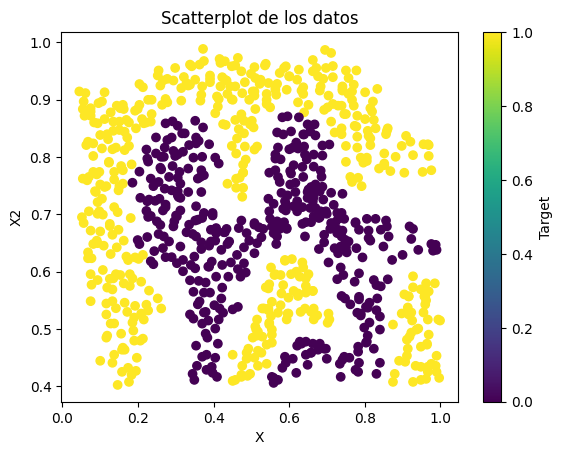

In [40]:
import matplotlib.pyplot as plt

plt.scatter(df_2["X"], df_2["X2"], c=df_2["target"], cmap="viridis")
plt.xlabel("X")
plt.ylabel("X2")
plt.title("Scatterplot de los datos")
plt.colorbar(label="Target")
plt.show()

For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [41]:
from sklearn.svm import SVC
svc = SVC(C=100, gamma=10, probability=True)

#### 5. Fit the classifier and get the score

In [42]:
X2 = df_2.drop("target", axis=1)
y2 = df_2["target"]

svc.fit(X2, y2)

,C,100
,kernel,'rbf'
,degree,3
,gamma,10
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

In [44]:
probs_0 = svc.predict_proba(X2)[:, 0]

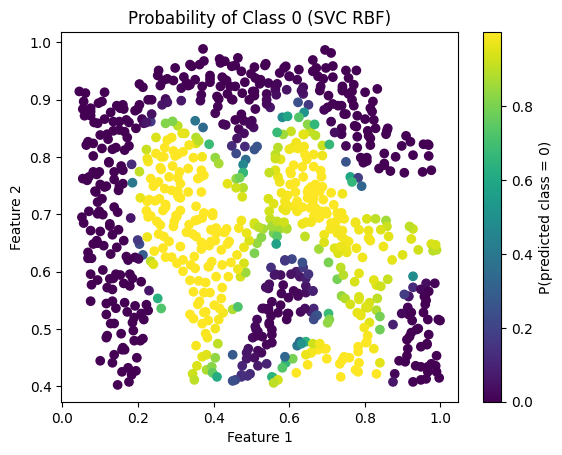

In [45]:
import matplotlib.pyplot as plt

plt.scatter(
    df_2["X"],
    df_2["X2"],
    c=probs_0,
    cmap="viridis"   # colormap secuencial recomendado
)

plt.colorbar(label="P(predicted class = 0)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Probability of Class 0 (SVC RBF)")
plt.show()
